# Weight Visualization Demo (TensorFlow) — Fashion‑MNIST
This demo notebook is designed for **lecture display** (concept-first).

It shows how to visualize:
- **Logistic regression (softmax) weights** as image templates
- **MLP first Dense** weights as “feature detectors”
- **MLP deeper layers** as **heatmaps** (no longer pixel-space)
- **Back‑projected templates** for the **output layer**
- (Optional) **CNN filters + feature maps**

Dataset: **Fashion‑MNIST** (auto-downloads).  


In [1]:
# If needed:
# !pip -q install tensorflow matplotlib numpy

import math, numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow: 2.20.0
GPU available: False


In [2]:
# Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Train/val split
val_size = 10000
x_val, y_val = x_train[-val_size:], y_train[-val_size:]
x_tr,  y_tr  = x_train[:-val_size], y_train[:-val_size]

print("Train:", x_tr.shape, "Val:", x_val.shape, "Test:", x_test.shape)


Train: (50000, 28, 28) Val: (10000, 28, 28) Test: (10000, 28, 28)


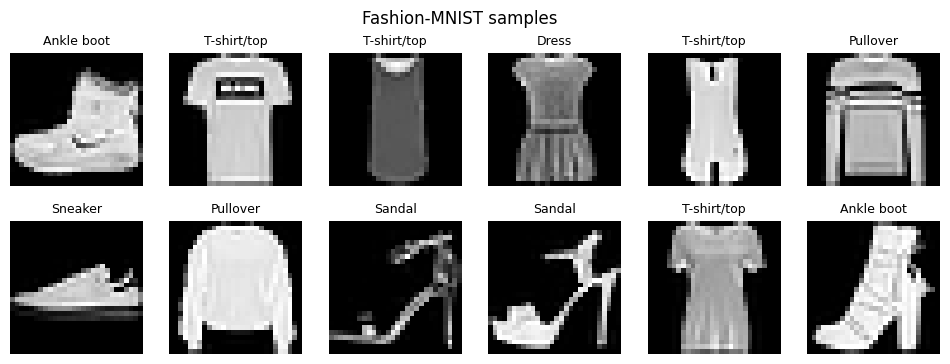

In [3]:
def show_images(images, labels=None, class_names=None, n=12, cols=6, title=None):
    plt.figure(figsize=(cols*2, math.ceil(n/cols)*2))
    for i in range(n):
        ax = plt.subplot(math.ceil(n/cols), cols, i+1)
        plt.imshow(images[i], cmap="gray")
        if labels is not None:
            lab = int(labels[i])
            plt.title(class_names[lab] if class_names else str(lab), fontsize=9)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

show_images(x_tr[:12], y_tr[:12], class_names, title="Fashion‑MNIST samples")


## Part A — Logistic Regression (Softmax) Templates
A linear classifier on pixels:
- Flatten 28×28 → 784
- Dense(10) + softmax

Weights shape: **(784, 10)**  
Each column is a class “template” in pixel space → reshape to 28×28.


In [6]:
# Train a quick logistic/softmax regression model (few epochs for lecture demo)
log_model = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(10, activation="softmax")
])

log_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

log_model.fit(x_tr, y_tr, validation_data=(x_val, y_val),
              epochs=10, batch_size=256, verbose=1)

test_loss, test_acc = log_model.evaluate(x_test, y_test, verbose=0)
print("Logistic regression test acc:", round(float(test_acc), 4))


Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7029 - loss: 0.9206 - val_accuracy: 0.7909 - val_loss: 0.6412
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.5878 - val_accuracy: 0.8159 - val_loss: 0.5518
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8268 - loss: 0.5258 - val_accuracy: 0.8271 - val_loss: 0.5117
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8357 - loss: 0.4951 - val_accuracy: 0.8305 - val_loss: 0.4905
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8411 - loss: 0.4742 - val_accuracy: 0.8368 - val_loss: 0.4756
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8457 - loss: 0.4604 - val_accuracy: 0.8431 - val_loss: 0.4669
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8475 - loss: 0.4501 - val_accuracy: 0.8421 - val_loss: 0.4574
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8515 - loss: 0.4405 - val_accuracy: 0.

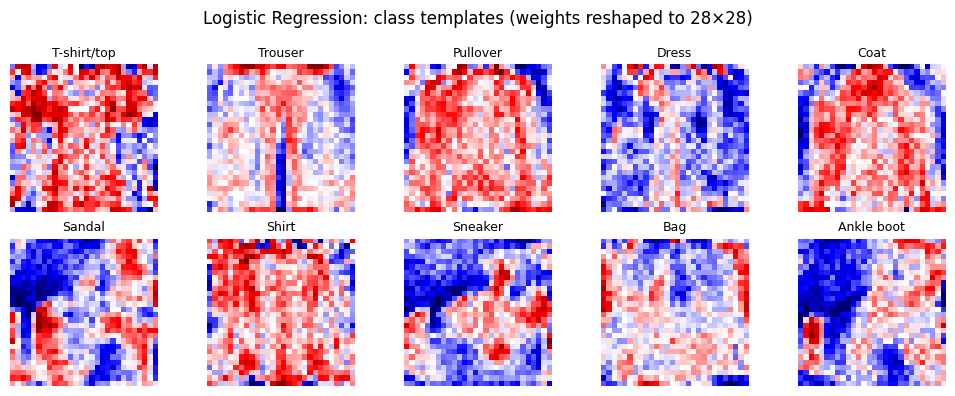

In [7]:
# Plot logistic regression weight templates (pixel-space)
W, b = log_model.layers[-1].get_weights()  # W: (784, 10)
W_img = W.reshape(28, 28, 10)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(W_img[:,:,i], cmap="seismic")
    plt.title(class_names[i], fontsize=9)
    plt.axis("off")
plt.suptitle("Logistic Regression: class templates (weights reshaped to 28×28)")
plt.tight_layout()
plt.show()


## Part B — MLP: First Dense Weights vs Deeper Dense Weights
Example MLP:
- Flatten → Dense(256, ReLU) → Dense(128, ReLU) → Dense(10, softmax)

Key idea:
- First Dense sees **pixels** → weights can be reshaped to **28×28**
- Second Dense sees **features** → weights are **feature-to-feature** (no 28×28 meaning)


In [19]:
# Train a quick MLP (few epochs for lecture demo)
mlp = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

mlp.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

mlp.fit(x_tr, y_tr, validation_data=(x_val, y_val),
        epochs=6, batch_size=256, verbose=1)

test_loss, test_acc = mlp.evaluate(x_test, y_test, verbose=0)
print("MLP test acc:", round(float(test_acc), 4))

# Print layer indices (so you can reference them safely)
for i, layer in enumerate(mlp.layers):
    print(i, layer.name, layer.__class__.__name__)


Epoch 1/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7997 - loss: 0.5755 - val_accuracy: 0.8538 - val_loss: 0.4299
Epoch 2/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8572 - loss: 0.3975 - val_accuracy: 0.8621 - val_loss: 0.3897
Epoch 3/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8749 - loss: 0.3495 - val_accuracy: 0.8711 - val_loss: 0.3643
Epoch 4/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8836 - loss: 0.3224 - val_accuracy: 0.8720 - val_loss: 0.3593
Epoch 5/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8889 - loss: 0.3041 - val_accuracy: 0.8799 - val_loss: 0.3312
Epoch 6/6
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8966 - loss: 0.2818 - val_accuracy: 0.8805 - val_loss: 0.3279
MLP test acc: 0.8751
0 flatten_4 Flatten
1 dense_7 Dense
2 dense_8 Dense
3 dense_9 Dense


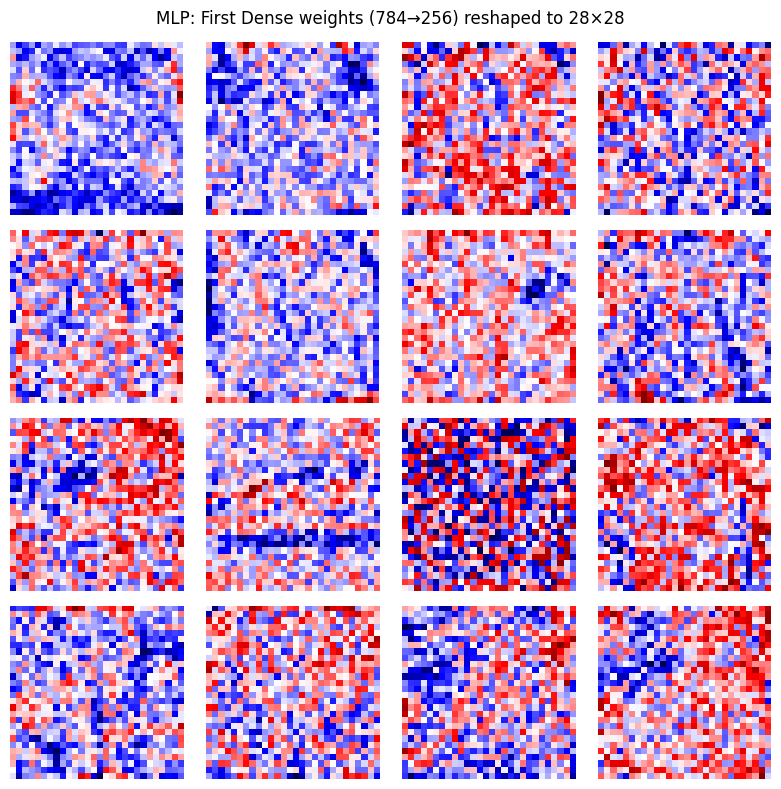

In [9]:
# 1) Plot FIRST Dense layer weights as 28×28 "feature detectors"
# Flatten is index 0, first Dense is index 1 (in THIS model)
W1, b1 = mlp.layers[1].get_weights()  # (784, 256)
W1_img = W1.reshape(28, 28, -1)

n = 16
plt.figure(figsize=(8,8))
for i in range(n):
    plt.subplot(4,4,i+1)
    plt.imshow(W1_img[:,:,i], cmap="seismic")
    plt.axis("off")
plt.suptitle("MLP: First Dense weights (784→256) reshaped to 28×28")
plt.tight_layout()
plt.show()


Second Dense weight shape: (256, 128)


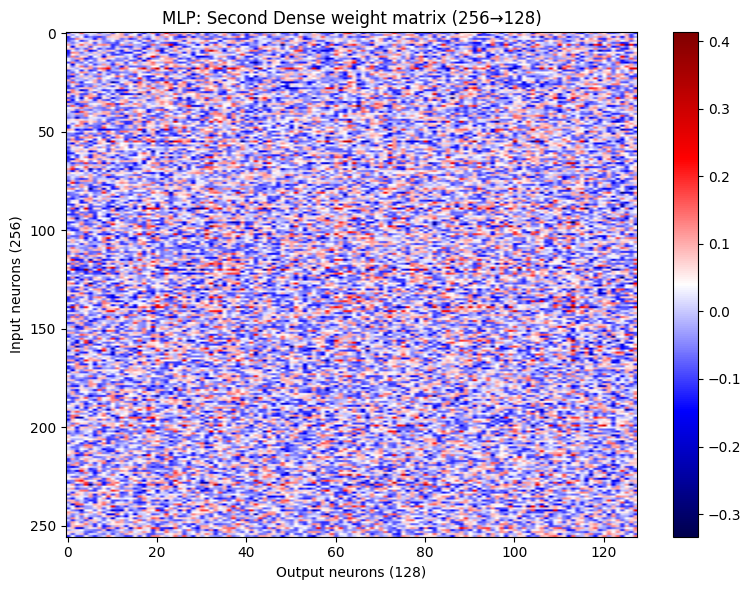

In [10]:
# 2) SECOND Dense layer weights are feature-to-feature (256→128) → visualize as a heatmap
W2, b2 = mlp.layers[2].get_weights()  # (256, 128)
print("Second Dense weight shape:", W2.shape)

plt.figure(figsize=(8,6))
plt.imshow(W2, aspect="auto", cmap="seismic")
plt.colorbar()
plt.title("MLP: Second Dense weight matrix (256→128)")
plt.xlabel("Output neurons (128)")
plt.ylabel("Input neurons (256)")
plt.tight_layout()
plt.show()


## Part C — Back‑project the Output Layer into Pixel Space (Very Useful)
Even though the output is probabilities, the output Dense layer still has weights.

To visualize what each class “looks for” **in pixels**, we can approximate an **effective template** by multiplying weights:

\[ W_{eff} \approx W_1 \cdot W_2 \cdot W_3 \]

Where:
- \(W_1\): pixels → hidden1
- \(W_2\): hidden1 → hidden2
- \(W_3\): hidden2 → classes

Result: \(W_{eff}\) is **pixels → classes** (784×10) → reshape to 28×28 templates.


Dense layers: ['dense_2', 'dense_3', 'dense_4']
W_eff shape: (784, 10)


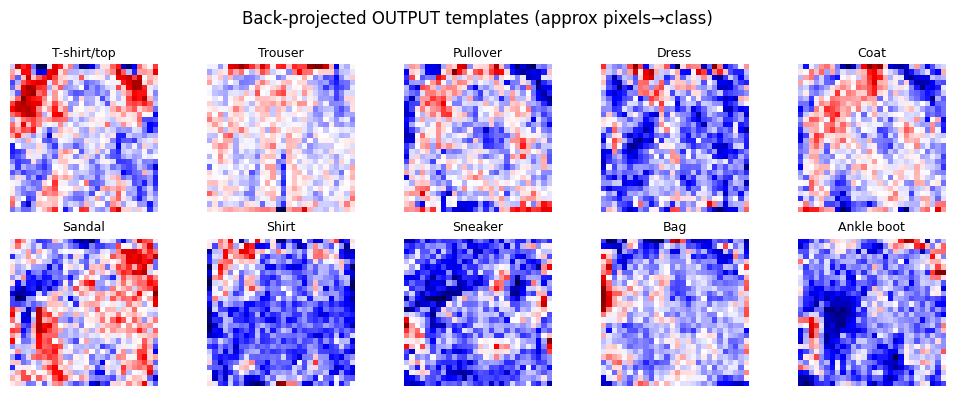

In [11]:
# Collect Dense weights (skip Flatten; it has no weights)
dense_layers = [layer for layer in mlp.layers if isinstance(layer, layers.Dense)]
print("Dense layers:", [l.name for l in dense_layers])

W1, _ = dense_layers[0].get_weights()  # (784, 256)
W2, _ = dense_layers[1].get_weights()  # (256, 128)
W3, _ = dense_layers[2].get_weights()  # (128, 10)

W_eff = W1 @ W2 @ W3  # (784, 10)
print("W_eff shape:", W_eff.shape)

W_eff_img = W_eff.reshape(28, 28, 10)

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(W_eff_img[:,:,i], cmap="seismic")
    plt.title(class_names[i], fontsize=9)
    plt.axis("off")
plt.suptitle("Back‑projected OUTPUT templates (approx pixels→class)")
plt.tight_layout()
plt.show()


In [46]:
import tensorflow as tf
tf.keras.backend.clear_session()

## Part D (Optional) — CNN Filters + Feature Maps
CNN first conv filters are naturally spatial (e.g., 3×3).  
We can plot:
- conv filters
- feature maps for one image

This is optional but impressive for students.


In [47]:
# Build + train a small CNN quickly
x_tr_cnn  = x_tr[...,  np.newaxis]
x_val_cnn = x_val[..., np.newaxis]
x_test_cnn= x_test[...,np.newaxis]

cnn = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cnn.fit(x_tr_cnn, y_tr, validation_data=(x_val_cnn, y_val),
        epochs=4, batch_size=256, verbose=1)

test_loss, test_acc = cnn.evaluate(x_test_cnn, y_test, verbose=0)
print("CNN test acc:", round(float(test_acc), 4))

for i, layer in enumerate(cnn.layers):
    print(i, layer.name, layer.__class__.__name__)


Epoch 1/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.7930 - loss: 0.5820 - val_accuracy: 0.8594 - val_loss: 0.3909
Epoch 2/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.8716 - loss: 0.3604 - val_accuracy: 0.8826 - val_loss: 0.3321
Epoch 3/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8882 - loss: 0.3139 - val_accuracy: 0.8900 - val_loss: 0.3059
Epoch 4/4
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.8987 - loss: 0.2834 - val_accuracy: 0.8951 - val_loss: 0.2968
CNN test acc: 0.8893
0 conv2d Conv2D
1 max_pooling2d MaxPooling2D
2 conv2d_1 Conv2D
3 max_pooling2d_1 MaxPooling2D
4 flatten Flatten
5 dense Dense
6 dense_1 Dense


Conv1 filter shape: (3, 3, 1, 32)


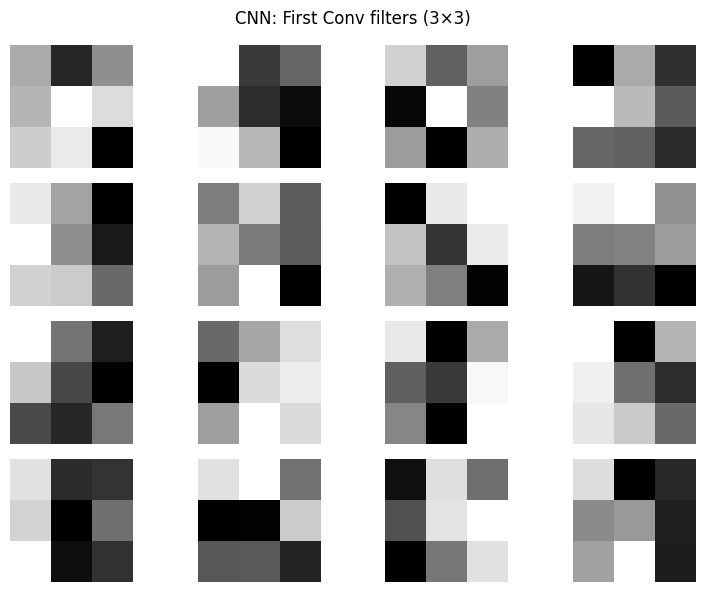

In [48]:
# 1) Plot first Conv2D filters
conv1 = None
for layer in cnn.layers:
    if isinstance(layer, layers.Conv2D):
        conv1 = layer
        break

filters, biases = conv1.get_weights()  # filters: (3,3,1,32)
print("Conv1 filter shape:", filters.shape)

n = min(16, filters.shape[-1])
plt.figure(figsize=(8,6))
for i in range(n):
    f = filters[:,:,:,i]
    f = (f - f.min()) / (f.max() - f.min() + 1e-8)  # normalize for display
    plt.subplot(4,4,i+1)
    plt.imshow(f[:,:,0], cmap="gray")
    plt.axis("off")
plt.suptitle("CNN: First Conv filters (3×3)")
plt.tight_layout()
plt.show()


In [49]:
# Force the model to be called once to create cnn.input/cnn.output tensors
_ = cnn(tf.zeros((1, 28, 28, 1)))

In [50]:
print(cnn.built)
print(cnn.inputs if hasattr(cnn, "inputs") else "no inputs")

True
[<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]


In [51]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         401,536 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,264,928 (4.83 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 843,286 (3.22 MB)

In [54]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Create a fresh symbolic input
inp = keras.Input(shape=(28, 28, 1))

x = inp
conv1_out = None

for layer in cnn.layers:
    x = layer(x)
    if layer.name == "conv2d":   # or: isinstance(layer, layers.Conv2D) and conv1_out is None
        conv1_out = x

feat_model = keras.Model(inputs=inp, outputs=conv1_out)

# Now run it
idx = 0
img = x_test_cnn[idx:idx+1]
fm = feat_model.predict(img, verbose=0)[0]  # (H,W,C)

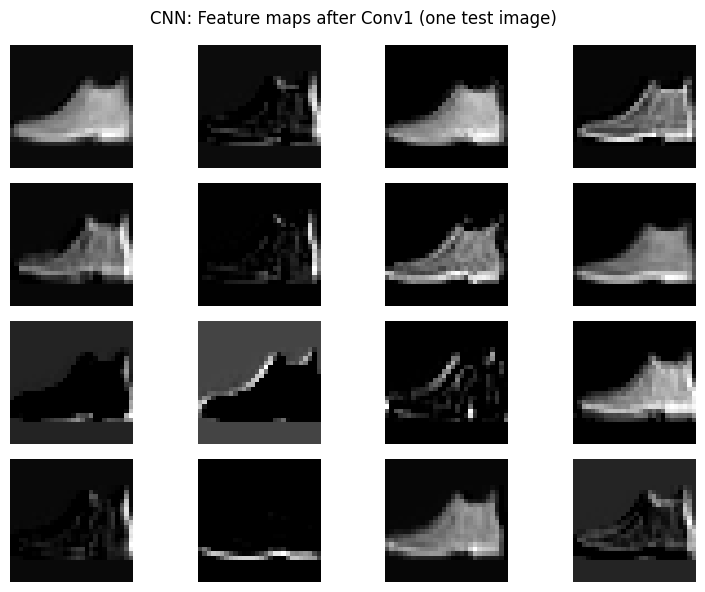

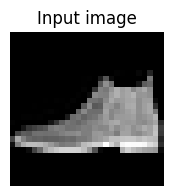

In [55]:
n = min(16, fm.shape[-1])
plt.figure(figsize=(8,6))
for i in range(n):
    plt.subplot(4,4,i+1)
    plt.imshow(fm[:,:,i], cmap="gray")
    plt.axis("off")
plt.suptitle("CNN: Feature maps after Conv1 (one test image)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(2,2))
plt.imshow(img[0,:,:,0], cmap="gray")
plt.title("Input image")
plt.axis("off")
plt.show()

## Teaching Notes (Quick Script)
- Logistic regression templates: “one template per class”
- MLP first layer: “feature detectors, not class detectors”
- Deeper dense layer: “feature-to-feature mixing (no pixel meaning)"
- Back-projected output: “what the class neuron roughly looks for in pixels”
- CNN filters: “local patterns + weight sharing”
